In [1]:
# Import necessary libraries
import os
from pathlib import Path
import numpy as np
import pandas as pd
from astropy import coordinates as coords
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table
from astropy.io import fits
from astropy.cosmology import LambdaCDM
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Set cosmology
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    
    # Tick direction and appearance
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,            # show top ticks
    'ytick.right': True,          # show right ticks
    'xtick.minor.visible': True,  # show minor x ticks
    'ytick.minor.visible': True,  # show minor y ticks
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    
    # Axes and line properties
    'lines.linewidth': 2,
    'axes.linewidth': 3.5,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})
# Pandas configuration
pd.set_option('display.max_columns', None)

# 0. Import Data

In [2]:
tng50_99_header = pd.read_csv('../../DATA/TNG50/TNG50_output_snapNum_99/Massive_Haloinfo_Snapnum99.csv')
tng50_96_header = pd.read_csv('../../DATA/TNG50/TNG50_output_snapNum_96/Massive_Haloinfo_Snapnum96.csv')

hparam = 0.6774

tng50_99_header['M200(solmass)']=np.log10(tng50_99_header['Group_M_Crit200']/hparam * 1e10)
tng50_96_header['M200(solmass)']=np.log10(tng50_96_header['Group_M_Crit200']/hparam * 1e10)

tng50_99_header['R200(Mpc)'] = tng50_99_header['Group_R_Crit200']/hparam * 1e-3
tng50_96_header['R200(Mpc)'] = tng50_96_header['Group_R_Crit200']/hparam * 1e-3

# R200이 A2199 비교할만큼 큰게 딱 하나 밖에 없음 그걸 재는 거임
tng50_99_halo0 = pd.read_csv('../../DATA/TNG50/TNG50_output_snapNum_99/HALOCAT/halo00000000_result.csv')
tng50_96_halo0 = pd.read_csv('../../DATA/TNG50/TNG50_output_snapNum_96/HALOCAT/halo00000000_result.csv')

# 1. Volume Normalization

In [3]:
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo
import numpy as np

# --- Find the two most separated subhalos (in 3D) in tng50_96_halo0 ---

# 1. Extract 3D positions for all subhalos (in Mpc)
coords = tng50_96_halo0[['Distance_X (Mpc)', 'Distance_Y (Mpc)', 'Distance_Z (Mpc)']].values

# 2. Select reference subhalo (ID=7870) and get its coordinates
target_row = tng50_96_halo0[tng50_96_halo0['SubhaloIndex'] == 7870]
target_coord = target_row[['Distance_X (Mpc)', 'Distance_Y (Mpc)', 'Distance_Z (Mpc)']].values.squeeze()

# 3. Calculate 3D distances from the reference subhalo to all other subhalos
diff = coords - target_coord  # shape (N, 3)
dists = np.linalg.norm(diff, axis=1)  # Euclidean norm, shape (N,)

# 4. Exclude distance to itself
dists[target_row.index[0]] = -np.inf  # Replace self-distance by -inf

# 5. Find subhalo farthest from the reference
max_idx = np.argmax(dists)
max_distance = dists[max_idx]
farthest_row = tng50_96_halo0.iloc[max_idx]

# Print the result
print(f"SubhaloIndex 7870과 가장 먼 SubhaloIndex {farthest_row['SubhaloIndex']}의 거리는 {max_distance:.3f} Mpc 입니다.")

# -- Prepare volume normalization (comoving) --

L_phys = max_distance  # length of the structure (in Mpc)

# Use mean radial distance from center as cylindrical radius (in physical Mpc)
r_phys = np.mean(tng50_96_halo0['Distance (Mpc)']) * u.Mpc

z = 0.03  # Adopted redshift
h = cosmo.H0.value / 100.0  # Dimensionless Hubble parameter

# Convert physical distances to comoving (divide by scale factor)
scale_factor = 1 / (1 + z)
r_comoving = r_phys / scale_factor  # comoving radius
L_comoving = L_phys / scale_factor  # comoving height

# Calculate comoving volume of cylinder (Mpc^3)
comoving_volume = np.pi * (r_comoving ** 2) * L_comoving

# Convert to h^-3 Mpc^3 units
volume_h3 = comoving_volume.value * h**3  # final volume (float)

SubhaloIndex 7870과 가장 먼 SubhaloIndex 65281의 거리는 5.018 Mpc 입니다.


# 2. LF Construction

Schechter Function Fit (MCMC)

100%|██████████| 5000/5000 [00:02<00:00, 1926.43it/s]


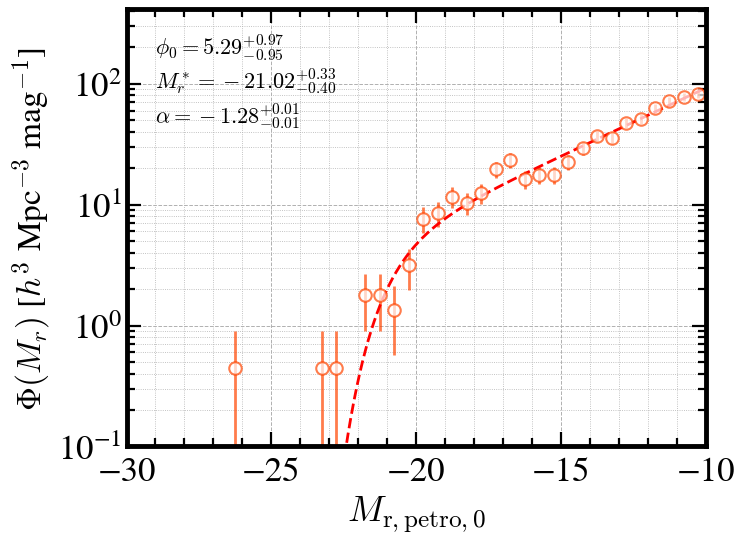

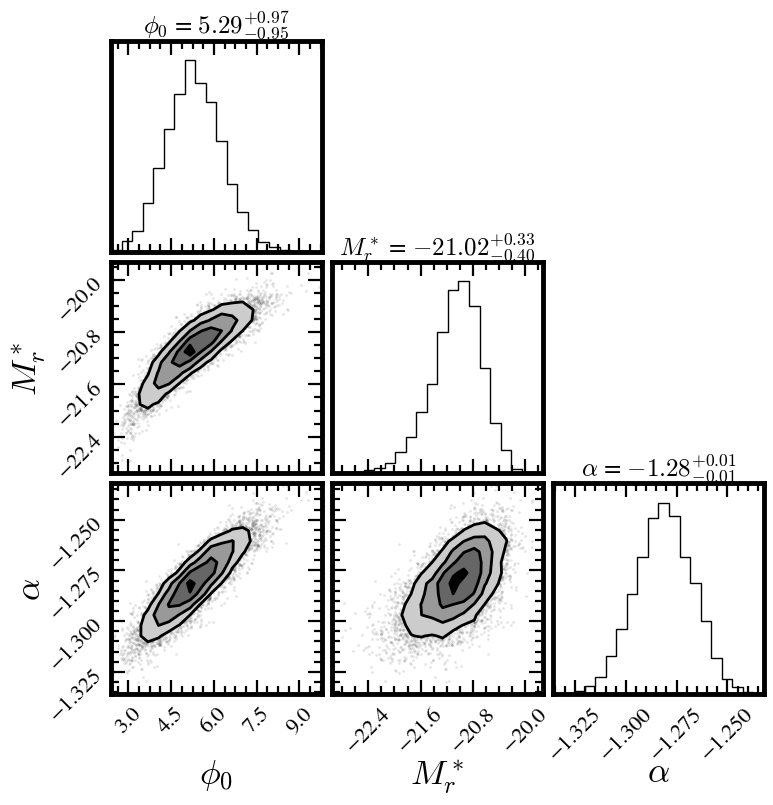

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import astropy.units as u
import emcee
from astropy.cosmology import Planck18 as cosmo
import corner

# --- Schechter function (single) ---
def schechter_1D_LF(M, phi_0, M_star, alpha):
    exp_term = 10.0**(0.4 * (M_star - M))
    return phi_0 * exp_term**(1 + alpha) * np.exp(-exp_term)

# --- Log-likelihood, prior, and posterior ---
def log_likelihood(theta, M, y, yerr):
    phi_0, M_star, alpha = theta
    model = schechter_1D_LF(M, phi_0, M_star, alpha)
    sigma2 = yerr**2
    return -0.5 * np.sum((y - model)**2 / sigma2 + np.log(2 * np.pi * sigma2))

def log_prior(theta):
    phi_0, M_star, alpha = theta
    # Uniform priors
    if 0 < phi_0 < 100 and -30 < M_star < -10 and -3 < alpha < 0:
        return 0.0
    return -np.inf

def log_probability(theta, M, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, M, y, yerr)

# --- Cosmology and volume ---
h = cosmo.H0.value / 100.0
z = 0.03
com_dist = cosmo.comoving_distance(z)
theta_rad = (30 * u.arcmin).to(u.radian)
trans_dist = com_dist * theta_rad / u.radian
cyl_volume = 3 * np.pi * trans_dist**3
volume_h3 = cyl_volume.value * h**3

# --- Data Preparation ---
bin_width = 0.5
bin_edges = np.arange(-30, -10 + bin_width, bin_width)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

df_plot = tng50_96_halo0[tng50_96_halo0['Subhalo_AbsMag_r'] < 0].copy()
df_plot['weight'] = 1

weights = df_plot['weight'].values
hist, _ = np.histogram(df_plot['Subhalo_AbsMag_r'], bins=bin_edges, weights=weights)
variance, _ = np.histogram(df_plot['Subhalo_AbsMag_r'], bins=bin_edges, weights=weights**2)
yerr = np.sqrt(np.maximum(variance, 0))

hist_density = hist / (bin_width * volume_h3)
yerr_density = yerr / (bin_width * volume_h3)

fit_min, fit_max = -30, -10
fit_mask = (bin_centers > fit_min) & (bin_centers < fit_max) & (hist_density > 0)
x_fit = bin_centers[fit_mask]
y_fit = hist_density[fit_mask]
yerr_fit = yerr_density[fit_mask]

# --- MCMC Fitting ---
init_params = np.array([10, -21.35, -1.24])
nwalkers = 32
ndim = init_params.size
pos = init_params + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x_fit, y_fit, yerr_fit))
sampler.run_mcmc(pos, 5000, progress=True)

samples = sampler.get_chain(discard=1000, thin=15, flat=True)

phi0_ci = np.percentile(samples[:,0], [16, 50, 84])
mstar_ci = np.percentile(samples[:,1], [16, 50, 84])
alpha_ci = np.percentile(samples[:,2], [16, 50, 84])

phi0_err = [phi0_ci[1] - phi0_ci[0], phi0_ci[2] - phi0_ci[1]]
mstar_err = [mstar_ci[1] - mstar_ci[0], mstar_ci[2] - mstar_ci[1]]
alpha_err = [alpha_ci[1] - alpha_ci[0], alpha_ci[2] - alpha_ci[1]]

phi0_med, mstar_med, alpha_med = phi0_ci[1], mstar_ci[1], alpha_ci[1]

# --- Plot the Schechter Fit ---
fig, ax = plt.subplots(figsize=(8, 6))

ax.axvspan(-30, fit_min, color='gray', alpha=0.7)
ax.axvspan(fit_max, -10, color='gray', alpha=0.7)

mask_pos = hist_density > 0
ax.errorbar(bin_centers[mask_pos], hist_density[mask_pos], yerr=yerr_density[mask_pos],
            fmt='o', color='orangered', ecolor='orangered', markerfacecolor='white',
            markeredgewidth=1.5, capsize=0, alpha=0.7, markersize=9)

x_model = np.linspace(-30, -10, 1000)
ax.plot(x_model, schechter_1D_LF(x_model, phi0_med, mstar_med, alpha_med), 
        color='red', linestyle='--', lw=2.0)

ax.set_yscale('log')
ax.set_xlim(-30, -10)
ax.set_ylim([1e-1, hist_density.max() * 5])

ax.set_xlabel(r'$M_\mathrm{r,petro,0}$', fontsize=26)
ax.set_ylabel(r'$\Phi(M_r)$ [$h^3$ Mpc$^{-3}$ mag$^{-1}$]', fontsize=24)

ax.grid(True, which='major', linestyle='--', linewidth=0.7)
ax.grid(True, which='minor', linestyle=':', linewidth=0.6)
ax.minorticks_on()
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

ann = (
    r"$\phi_0 = {:.2f}^{{+{:.2f}}}_{{-{:.2f}}}$".format(phi0_med, phi0_err[1], phi0_err[0]) + '\n' +
    r"$M^*_r = {:.2f}^{{+{:.2f}}}_{{-{:.2f}}}$".format(mstar_med, mstar_err[1], mstar_err[0]) + '\n' +
    r"$\alpha = {:.2f}^{{+{:.2f}}}_{{-{:.2f}}}$".format(alpha_med, alpha_err[1], alpha_err[0])
)
ax.text(0.05, 0.95, ann, transform=ax.transAxes, fontsize=16,
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='none', edgecolor='none', alpha=0.8))

plt.tight_layout()
plt.show()

# --- MCMC corner plot ---
labels = [r"$\phi_0$", r"$M^*_r$", r"$\alpha$"]

fig = corner.corner(samples, labels=labels,
                    show_titles=True,
                    title_fmt='.2f',
                    title_kwargs={"fontsize": 18},
                    plot_contours=True,
                    fill_contours=True,
                    fig=plt.figure(figsize=(8, 8))
)

for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=16)

plt.show()

# Save fit data points to CSV
df_fit = pd.DataFrame({
    'M_r': x_fit,
    'Phi': y_fit,
    'Phi_err': yerr_fit
})
df_fit.to_csv('TNG50_Halo0_LF.csv', index=False)